<a href="https://colab.research.google.com/github/juacastanori/SyS/blob/main/Ej_PSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Ejercicio - Juan Jerónimo Castaño Rivera

Hallar la PSD (función de densidad espectral) de $x(t)=A rect_τ (t)$

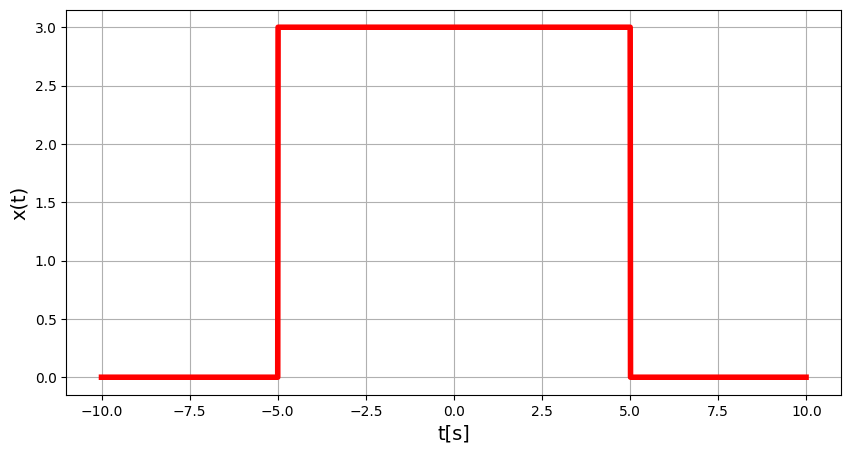

In [184]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
#definimos la funcion x(t)
A = 3 # amplitud de la señal
T = 10 # segundos de gráfica
Fo = 1/T
Fs = 1000*Fo # frecuencia de muestreo definida
tv = np.arange(-T,T,1/Fs) #vector de tiempo generado
Nm = len(tv) #numero de muestras requeridas

#
x = np.zeros(Nm)
x[(tv>=-T/2)&(tv<=T/2)] = A
#graficar señal original
plt.plot(tv,x,'r',linewidth=4)
plt.grid()
plt.xlabel("t[s]",fontsize = 14)
plt.ylabel("x(t)",fontsize = 14)
plt.show()


La ventana de Hanning (también conocida como ventana de Hann) es una función matemática utilizada en el procesamiento de señales, especialmente en la transformación de Fourier, para reducir los efectos de las discontinuidades en los bordes de un conjunto de datos. Es un tipo de ventana que suaviza las señales al aplicar un filtro que reduce el impacto de los extremos de la señal.

Definición Matemática
La ventana de Hanning se define matemáticamente como:
$w[n]=0.5(1-cos(\frac{2πn}{N-1}))$
donde:

- n es el índice de la muestra (0, 1, 2, ..., N-1).

- N es el número total de muestras.

Luego se puede calcular la PSD usando el método de Welch de scipy:

El método de Welch es una técnica utilizada para estimar la densidad espectral de potencia (PSD) de una señal.

Pasos Básicos del Método de Welch
Segmentación: Divide la señal en segmentos o ventanas más pequeñas. Cada ventana debe ser lo suficientemente larga para capturar la información relevante pero corta para reducir el efecto de variaciones a lo largo del tiempo. En tu caso, estás usando una ventana de Hanning, que es útil para suavizar la señal y reducir el efecto de fuga espectral.

Aplicación de Ventana: Aplica una ventana (en nuestro caso, una ventana de Hanning) a cada segmento. La ventana ayuda a reducir el efecto de las discontinuidades en los bordes de los segmentos, lo cual puede provocar distorsiones en la estimación espectral.

Transformada de Fourier: Realiza la Transformada de Fourier Discreta (DFT) sobre cada segmento ventana. Esto convierte la señal del dominio del tiempo al dominio de la frecuencia para cada segmento.

Cálculo de la PSD: Calcula la densidad espectral de potencia para cada segmento tomando el cuadrado del módulo de la DFT y promediándolo sobre todos los segmentos. Esto promedia las estimaciones espectrales de cada segmento para obtener una estimación más precisa y robusta de la PSD de la señal original.

Promediado: Promedia las estimaciones espectrales obtenidas de cada ventana para obtener la PSD final. Este paso ayuda a reducir el ruido y a obtener una estimación más precisa de la distribución de la potencia en función de la frecuencia.

Mean value of the periodogram: 0.112388


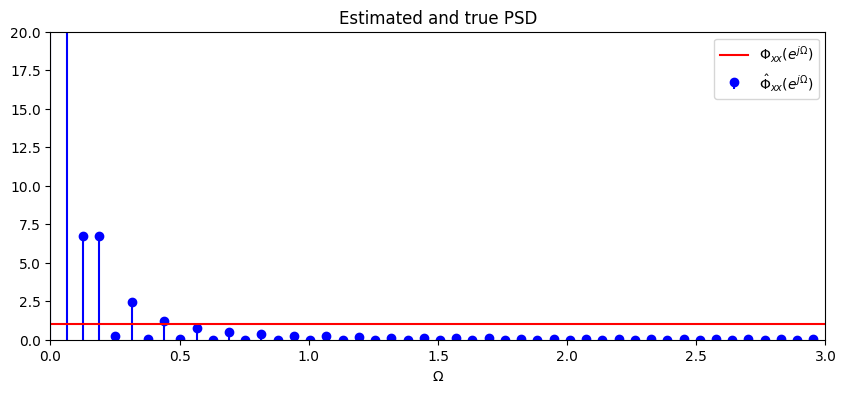

In [198]:
# compute periodogram by Welch's method
nf, Pxx = sig.welch(x, fs=Fs/5, window='hann', nperseg=Nm, noverlap=Nm//16)
Pxx = .5*Pxx  # due to normalization in scipy.signal
Om = 2*np.pi*nf

# plot results
plt.figure(figsize=(10,4))
plt.stem(Om, Pxx, 'b', label=r'$\hat{\Phi}_{xx}(e^{j \Omega})$', basefmt=' ')
plt.plot(Om, np.ones_like(Pxx), 'r', label=r'$\Phi_{xx}(e^{j \Omega})$')
plt.title('Estimated and true PSD')
plt.xlabel(r'$\Omega$')
plt.axis([0, 3, 0, 20])
plt.legend()

# compute mean value of the periodogram
print('Mean value of the periodogram: %f' %np.mean(np.abs(Pxx)))

Calculando el espectro teóricamente:

Imagen:

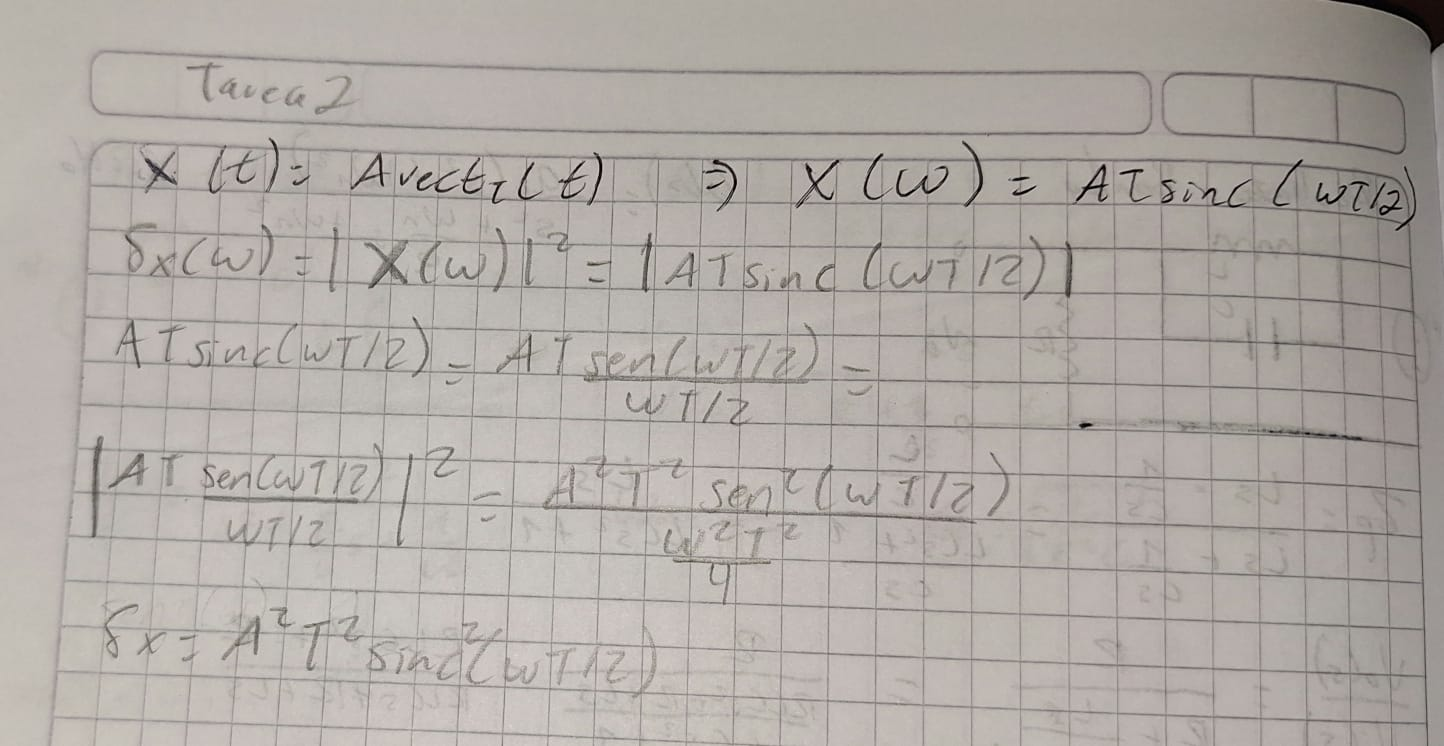

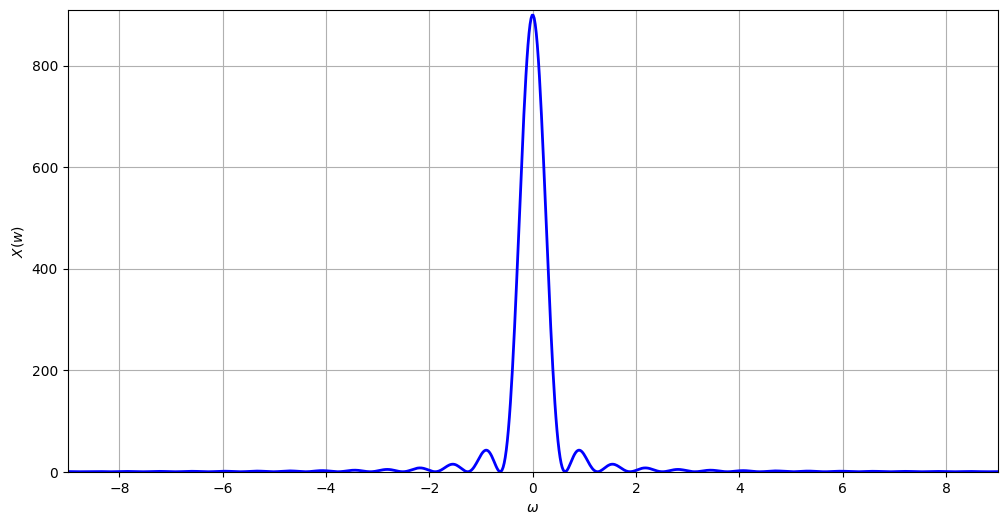

In [183]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
A = 3  # Amplitud
T = 10  # Duración del pulso (en segundos)

# Definir la función sinc
def sinc(x):
    return np.sin(x) / x

# Rango de frecuencias
omega = np.linspace(-10, 10, 1000)  # Rango de frecuencias en radianes por segundo

# Calcular la función A^2 T^2 sinc^2(wT/2)
sinc_argument = omega * T / 2
sinc_squared = (A**2) * (T**2) * (sinc(sinc_argument))**2

# Graficar la función
plt.figure(figsize=(12, 6))
plt.plot(omega, sinc_squared, 'b', linewidth=2)
plt.xlabel(r'$\omega$ ')
plt.ylabel(r'$X(w)$')
plt.axis([-9, 9, 0, 910])
plt.grid()
plt.show()